In [ ]:
!uv pip install "napari[all]>=0.6.2"

Audited 1 package in 32ms


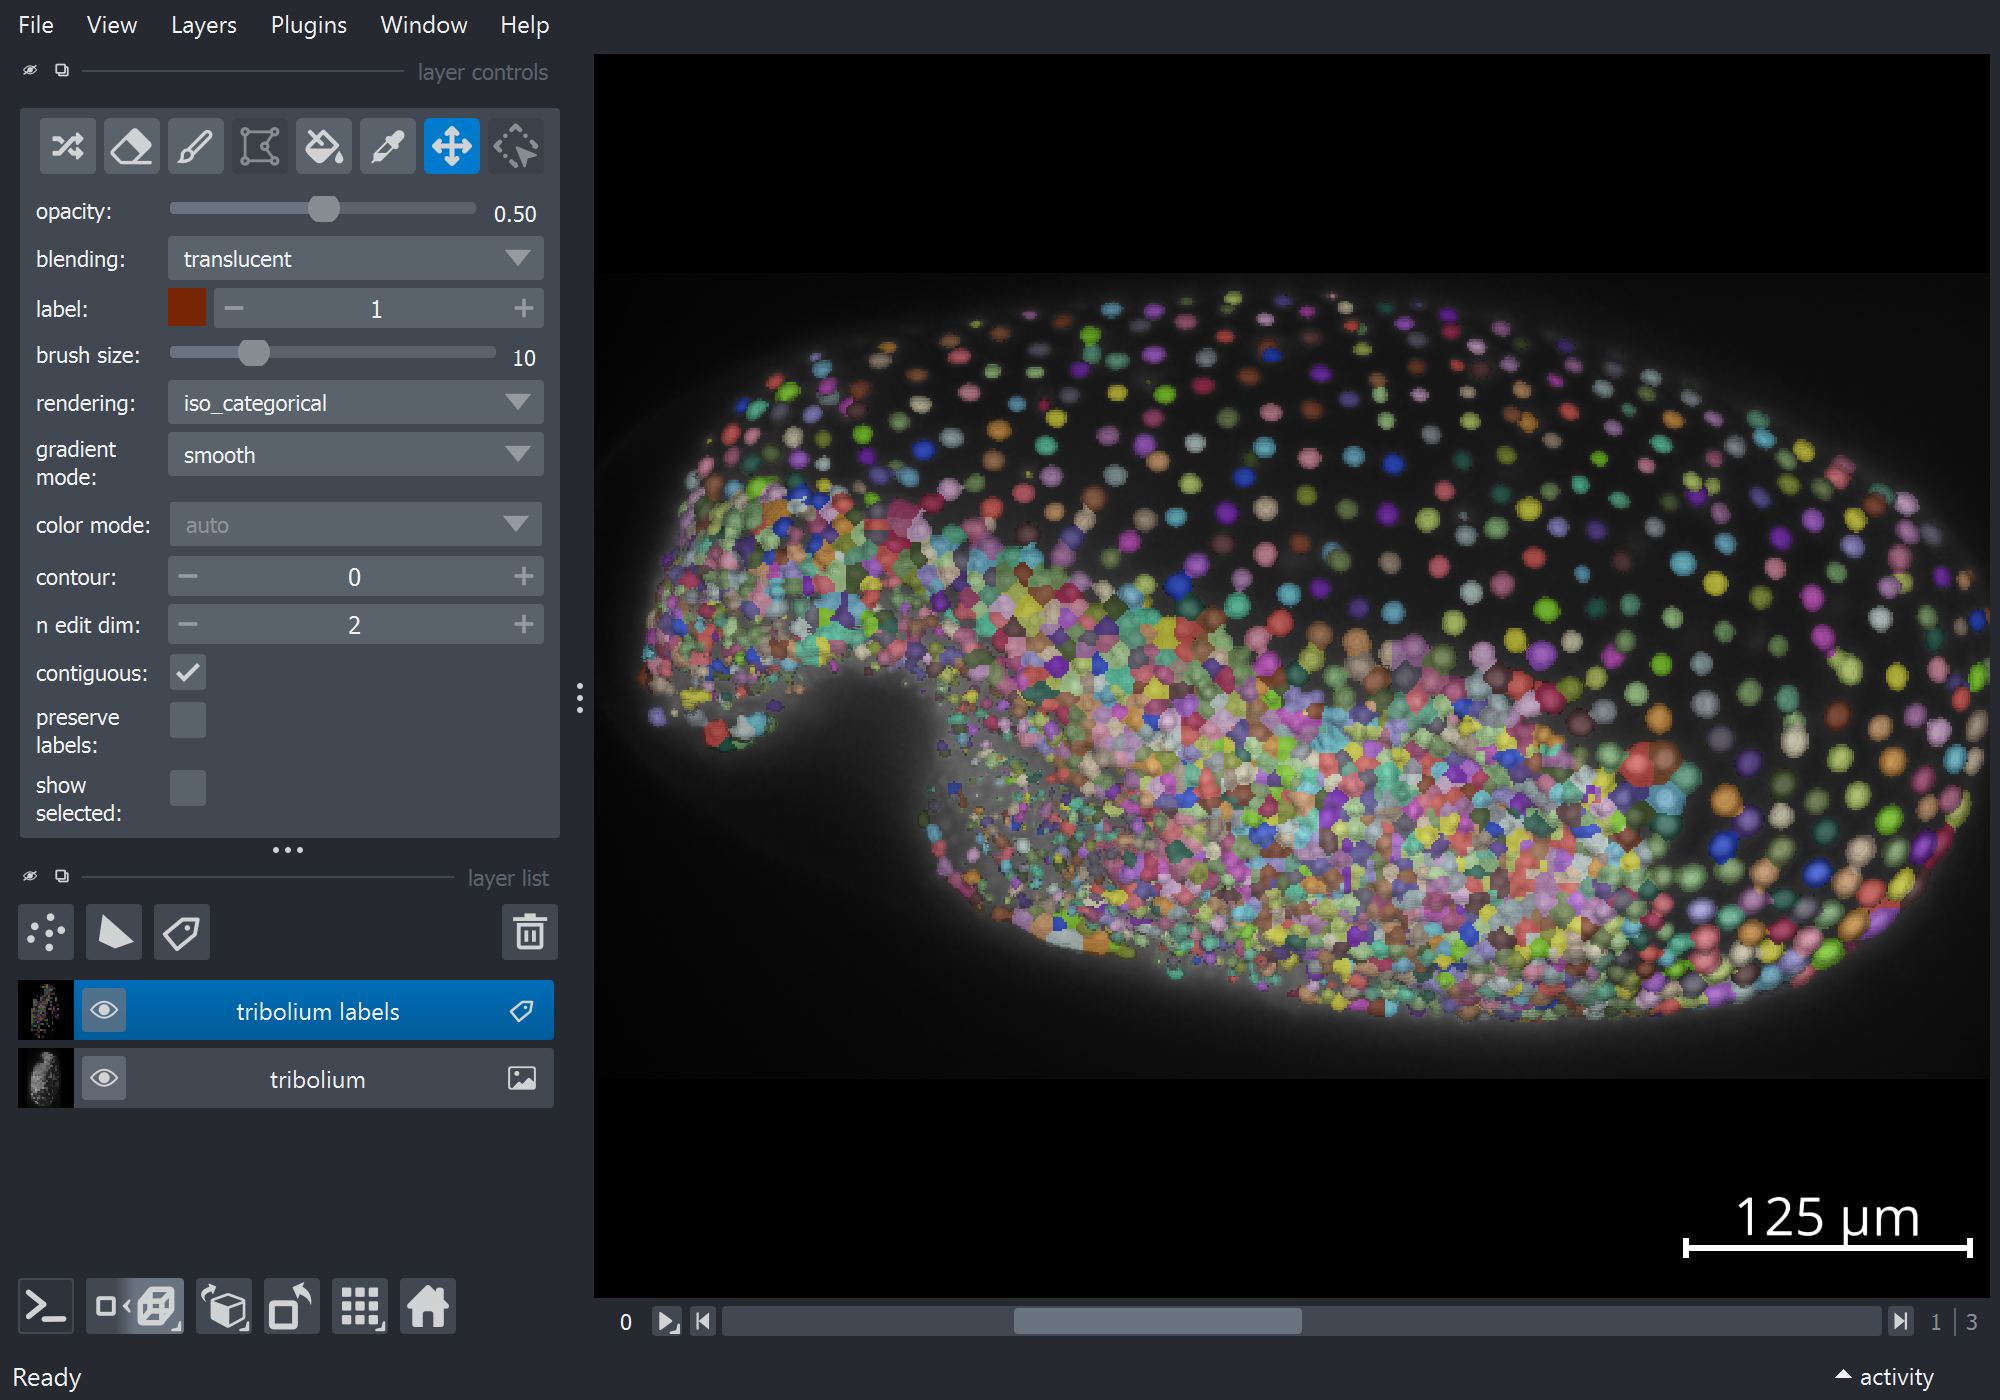

In [3]:
import numpy as np
import scipy.ndimage as ndimage
from skimage import filters, measure, morphology, segmentation
from skimage.io import imread


import napari
from napari.utils import nbscreenshot

# TZYX tribolium image
raw_image = imread(r'https://github.com/clEsperanto/clesperanto_example_data/raw/main/Lund-100MB.tif')

labels = np.zeros_like(raw_image, dtype=np.uint16)

for t in range(raw_image.shape[0]):
    img = raw_image[t, :, :, :]
    # use a tophat filter to remove the background
    img_bs = ndimage.white_tophat(img, size = 15)

    # blur the image to smooth out noise from the background subtraction
    img_blur = filters.gaussian(img_bs, 1)

    # detect maxima in the blurred image for watershed seeds
    img_spot_maxima = morphology.local_maxima(img_blur)

    # create a threshold mask
    img_otsu = img_blur > filters.threshold_otsu(img_blur)

    # keep only maxima spots that are inside a thresholded area
    img_threshold_spots = img_spot_maxima * img_otsu

    # create a connected components labeling of the thresholded image
    # using the local maxima as markers, as a seed for a voronoi diagram
    img_labeled_spots = measure.label(img_threshold_spots)
    img_labels = segmentation.watershed(
        img_otsu,
        markers=img_labeled_spots,
        mask=img_otsu
    )
    
    labels[t, :, :, :] = img_labels

viewer = napari.Viewer()

viewer.add_image(raw_image, name='tribolium')
viewer.add_labels(
    labels,
    name='tribolium labels',
    opacity=0.5,
    iso_gradient_mode = 'smooth'
)

viewer.dims.ndisplay = 3
viewer.camera.angles = (90, 0, 90)
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'μm'
viewer.scale_bar.font_size = 20

viewer.window.resize(1000, 700)
viewer.fit_to_view(margin=0)

screenshot = viewer.screenshot(path='tribolium_viewer.png', canvas_only=False)

nbscreenshot(viewer)